In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
subscription = pd.read_csv('../ravenstack_subscriptions.csv')

In [3]:
subscription.head()

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,False,False,False,True,monthly,True
1,S-0f6f44,A-9b9fe9,2024-06-11,NaN,Pro,17,833,9996,False,False,False,False,monthly,True
2,S-51c0d1,A-659280,2024-11-25,NaN,Enterprise,62,0,0,True,True,False,False,annual,False
3,S-f81687,A-e7a1e2,2024-11-23,2024-12-13,Enterprise,5,995,11940,False,False,False,True,monthly,True
4,S-cff5a2,A-ba6516,2024-01-10,NaN,Enterprise,27,5373,64476,False,False,False,False,monthly,True


In [4]:
# fixing date column
subscription['start_date'] = pd.to_datetime(subscription['start_date'])
subscription['end_date'] = pd.to_datetime(subscription['end_date'])

In [5]:
subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   subscription_id    5000 non-null   object        
 1   account_id         5000 non-null   object        
 2   start_date         5000 non-null   datetime64[ns]
 3   end_date           486 non-null    datetime64[ns]
 4   plan_tier          5000 non-null   object        
 5   seats              5000 non-null   int64         
 6   mrr_amount         5000 non-null   int64         
 7   arr_amount         5000 non-null   int64         
 8   is_trial           5000 non-null   bool          
 9   upgrade_flag       5000 non-null   bool          
 10  downgrade_flag     5000 non-null   bool          
 11  churn_flag         5000 non-null   bool          
 12  billing_frequency  5000 non-null   object        
 13  auto_renew_flag    5000 non-null   bool          
dtypes: bool(

In [6]:
# adding month column
subscription['year_and_month'] = subscription['start_date'].dt.to_period('M')

# adding month name column
subscription['month'] = subscription['start_date'].dt.month_name()
# adding year column
subscription['year'] = subscription['start_date'].dt.year

# adding status column
subscription['status'] = np.where(subscription['end_date'].isna(),'Active','Inactive')

In [7]:
subscription.to_csv('cleaned_subscription_data.csv',index = False)

In [8]:
subscription

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag,year_and_month,month,year,status
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,False,False,False,True,monthly,True,2023-12,December,2023,Inactive
1,S-0f6f44,A-9b9fe9,2024-06-11,NaT,Pro,17,833,9996,False,False,False,False,monthly,True,2024-06,June,2024,Active
2,S-51c0d1,A-659280,2024-11-25,NaT,Enterprise,62,0,0,True,True,False,False,annual,False,2024-11,November,2024,Active
3,S-f81687,A-e7a1e2,2024-11-23,2024-12-13,Enterprise,5,995,11940,False,False,False,True,monthly,True,2024-11,November,2024,Inactive
4,S-cff5a2,A-ba6516,2024-01-10,NaT,Enterprise,27,5373,64476,False,False,False,False,monthly,True,2024-01,January,2024,Active
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,S-c158df,A-fa2041,2024-10-27,NaT,Enterprise,18,3582,42984,False,False,False,False,monthly,True,2024-10,October,2024,Active
4996,S-b49c0a,A-db5e9e,2024-12-05,NaT,Pro,23,1127,13524,False,False,False,False,monthly,False,2024-12,December,2024,Active
4997,S-42822d,A-443f6f,2024-12-15,NaT,Pro,25,1225,14700,False,False,False,False,annual,True,2024-12,December,2024,Active
4998,S-432401,A-c7ffc2,2023-05-25,NaT,Pro,132,6468,77616,False,False,False,False,monthly,True,2023-05,May,2023,Active


In [9]:
monthly_mrr = (subscription.groupby('year_and_month')['mrr_amount'].sum().reset_index().sort_values('year_and_month'))

In [10]:
# monthly_mrr['year_and_month']  = pd.to_datetime(monthly_mrr['year_and_month'])
monthly_mrr

,year_and_month,mrr_amount
0,2023-01,4684
1,2023-02,11079
2,2023-03,25885
3,2023-04,41788
4,2023-05,85919
5,2023-06,74987
6,2023-07,120422
7,2023-08,165621
8,2023-09,116222
9,2023-10,182518


In [11]:
# highest mrr and lowest mrr
print('highest mrr')
print(monthly_mrr.loc[monthly_mrr['mrr_amount'].idxmax()])
print('lowest mrr')
print(monthly_mrr.loc[monthly_mrr['mrr_amount'].idxmin()])

highest mrr
year_and_month    2024-12
mrr_amount        2273427
Name: 23, dtype: object
lowest mrr
year_and_month    2023-01
mrr_amount           4684
Name: 0, dtype: object


1. Highest Revenue in December 2024

2. Lowest Revenue in January 2023

3. MRR grew from ₹4,684 in Jan-2023 to ₹2,273,427 in Dec-2024.

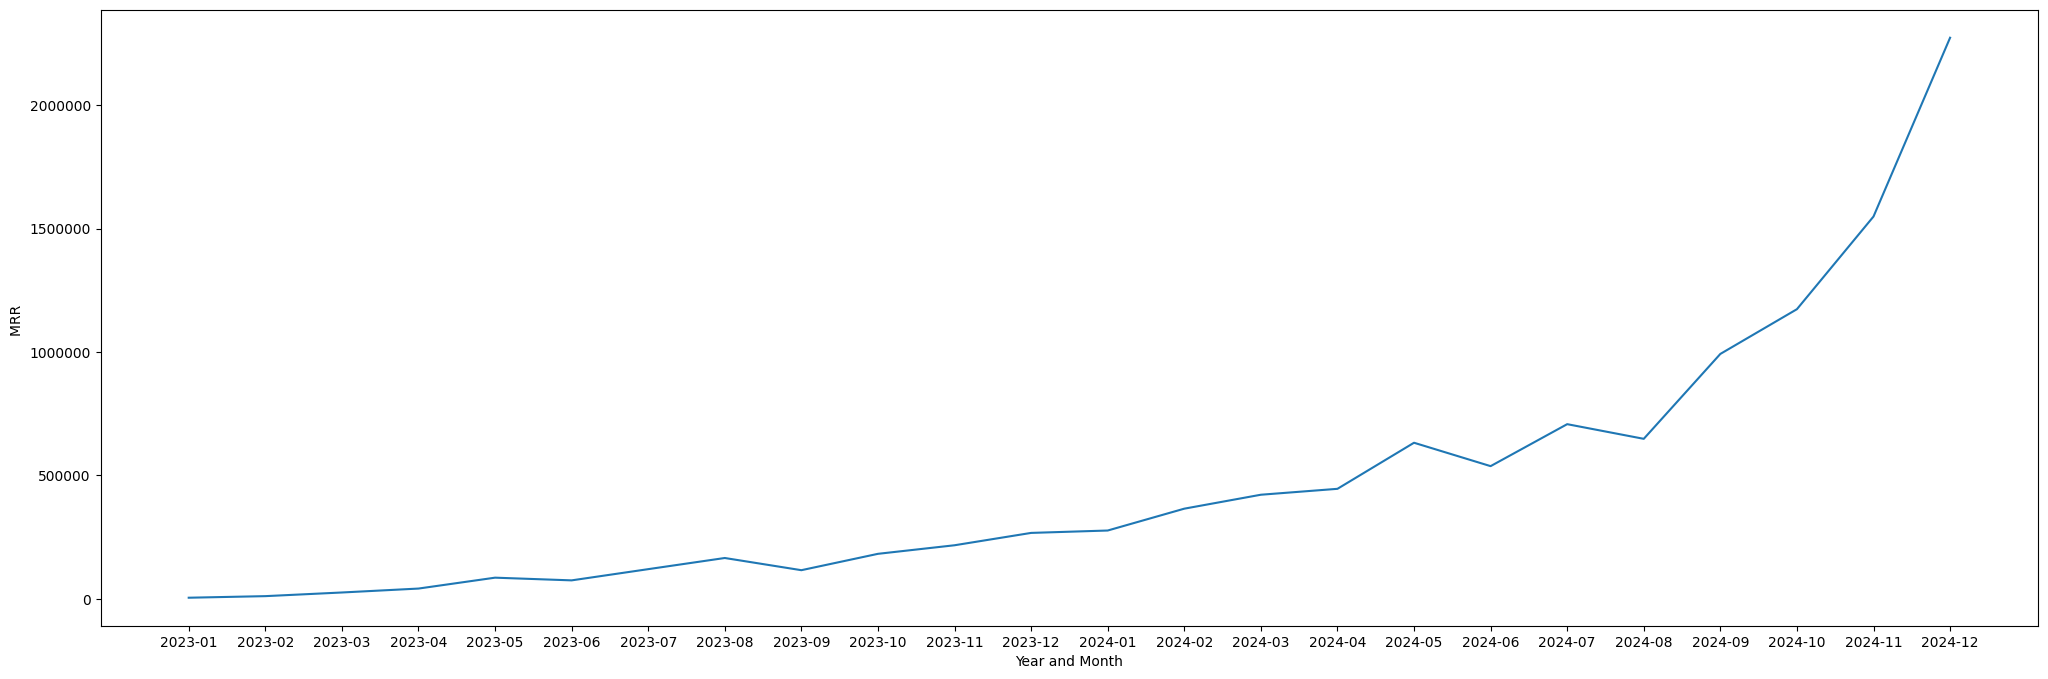

In [59]:
# line chart

x = monthly_mrr['year_and_month'].astype(str)
y = monthly_mrr['mrr_amount']

plt.figure(figsize = (25,8))
plt.xlabel('Year and Month')
plt.ylabel('MRR ')
plt.plot(x,y)
plt.ticklabel_format(style = 'plain',axis = 'y')
plt.show()

1. Revenue is increased steadily throughout the period.

In [15]:
active_cust = subscription[subscription['status'] == 'Active']
active_cust.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4514 entries, 1 to 4999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   subscription_id    4514 non-null   object        
 1   account_id         4514 non-null   object        
 2   start_date         4514 non-null   datetime64[ns]
 3   end_date           0 non-null      datetime64[ns]
 4   plan_tier          4514 non-null   object        
 5   seats              4514 non-null   int64         
 6   mrr_amount         4514 non-null   int64         
 7   arr_amount         4514 non-null   int64         
 8   is_trial           4514 non-null   bool          
 9   upgrade_flag       4514 non-null   bool          
 10  downgrade_flag     4514 non-null   bool          
 11  churn_flag         4514 non-null   bool          
 12  billing_frequency  4514 non-null   object        
 13  auto_renew_flag    4514 non-null   bool          
 14  year_and_mont

In [52]:
monthly_active_cust = active_cust.groupby('year_and_month')['account_id'].nunique().reset_index().rename(columns = {'account_id':'active_cust'})
monthly_active_cust

,year_and_month,active_cust
0,2023-01,2
1,2023-02,6
2,2023-03,15
3,2023-04,24
4,2023-05,22
5,2023-06,34
6,2023-07,38
7,2023-08,58
8,2023-09,39
9,2023-10,59


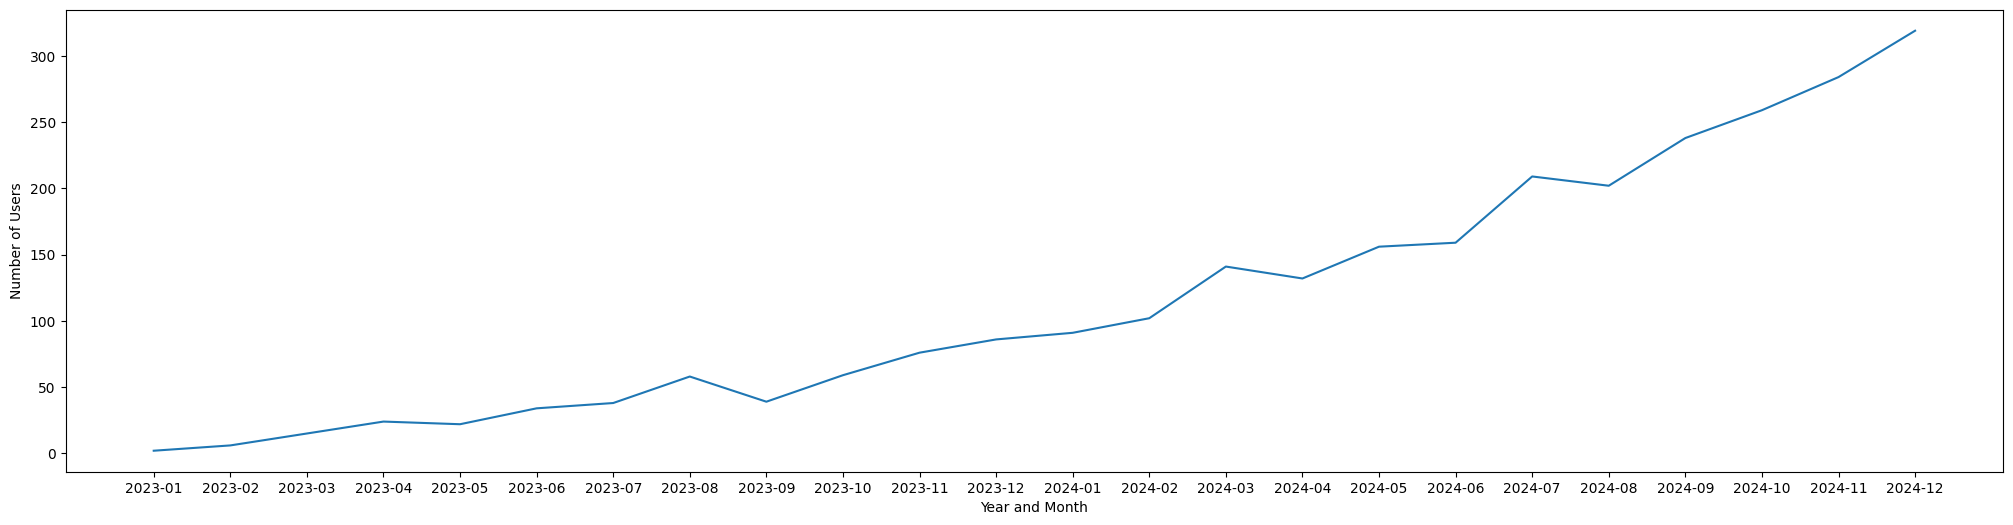

In [61]:
#  line chart for monthly active customer 2

x = monthly_active_cust['year_and_month'].astype(str)
y = monthly_active_cust['active_cust']

plt.figure(figsize = (25,6))
plt.xlabel('Year and Month')
plt.ylabel('Number of Users')
plt.plot(x,y)
plt.show()


1. Active customer count increased steadily throughout the period.

In [12]:
# revenue by plan

monthly_mrr_byPlan = subscription.groupby(['year_and_month','plan_tier'])['mrr_amount'].sum().reset_index()
monthly_mrr_byPlan


,year_and_month,plan_tier,mrr_amount
0,2023-01,Basic,171
1,2023-01,Enterprise,3582
2,2023-01,Pro,931
3,2023-02,Basic,570
4,2023-02,Enterprise,4776
...,...,...,...
67,2024-11,Enterprise,1210318
68,2024-11,Pro,241423
69,2024-12,Basic,144305
70,2024-12,Enterprise,1652695


In [13]:
monthly_mrr_byPlan.to_csv('monthly_mrr_byPlan.csv',index = False)

In [47]:
# total_rev_byplan
monthly_mrr_byPlan.groupby('plan_tier')['mrr_amount'].sum()

plan_tier
Basic          760437
Enterprise    8473221
Pro           2105089
Name: mrr_amount, dtype: int64

1. Enterprise contributes the largest share of revenue.

2. Pro contributes the second-largest share.

3. Basic contributes the smallest share.

In [66]:
active_cust_byPlan = active_cust.groupby('plan_tier')['account_id'].nunique().reset_index()
active_cust_byPlan

,plan_tier,account_id
0,Basic,472
1,Enterprise,474
2,Pro,468
